In [15]:
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import numpy as np
from scipy import stats
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    RandomizedSearchCV,
    GridSearchCV,
)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
)
from sklearn.svm import SVR
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.cluster import KMeans

In [831]:
dft = pd.read_csv("D:\\database\\csv files\\Telco-Customer-Churn.csv")
df = dft.copy()
# df = df.drop(columns=["CustomerID"])

In [832]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [833]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [834]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [836]:
df.dropna(inplace=True)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Creating customer Tenure Groups 

In [837]:
def tenure_group(x):
    if x <= 12:
        return "New"
    elif x <= 36:
        return "Mid"
    else:
        return "Long"


df["TenureGroup"] = df["tenure"].apply(tenure_group)

counting how many sevices customer using

In [838]:
services = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

df["ServiceCount"] = df[services].apply(lambda x: x.str.contains("Yes").sum(), axis=1)

Month-To-Month Charges

In [839]:
df["AvgCharges"] = df["TotalCharges"] / df["tenure"]

In [840]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServiceCount,AvgCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,New,1,29.850000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,Mid,3,55.573529
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,New,3,54.075000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,Long,3,40.905556
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,New,1,75.825000


Churn Count

<Axes: xlabel='Churn', ylabel='count'>

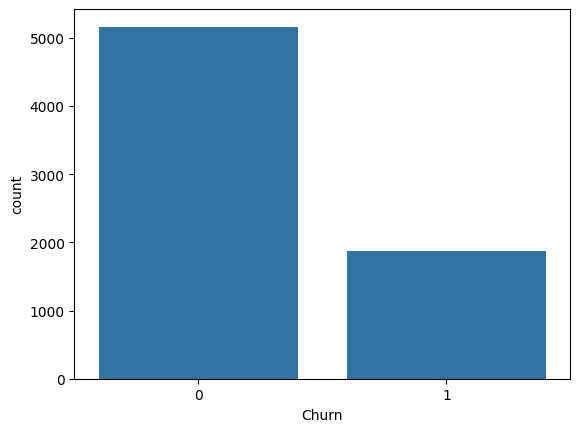

In [841]:
sns.countplot(x="Churn", data=df)

Churn By Contract

In [842]:
Churn_by_contract = pd.crosstab(df["Contract"], df["Churn"])
Churn_by_contract

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


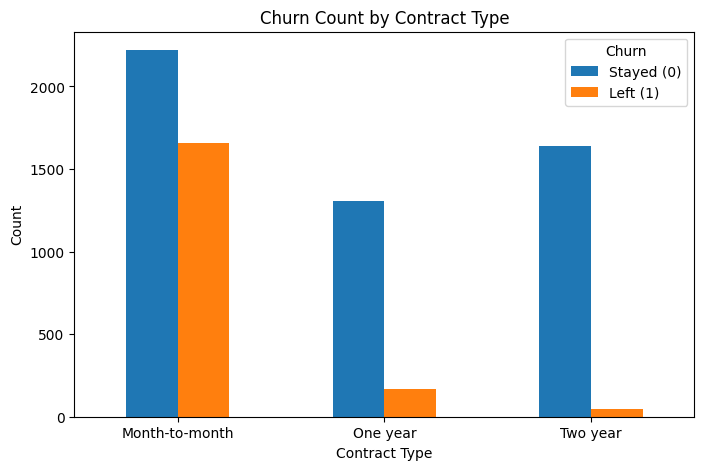

In [843]:
Churn_by_contract.plot(kind="bar", stacked=False, figsize=(8, 5), rot=0)
plt.title("Churn Count by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(title="Churn", labels=["Stayed (0)", "Left (1)"])
plt.show()

Customers with month-to-month contracts show significantly higher churn rates compared to long-term contracts.

Churn By Tenure

In [844]:
Churn_by_tenure = pd.crosstab(df["TenureGroup"], df["Churn"])
Churn_by_tenure

Churn,0,1
TenureGroup,,
Long,2643,358
Mid,1382,474
New,1138,1037


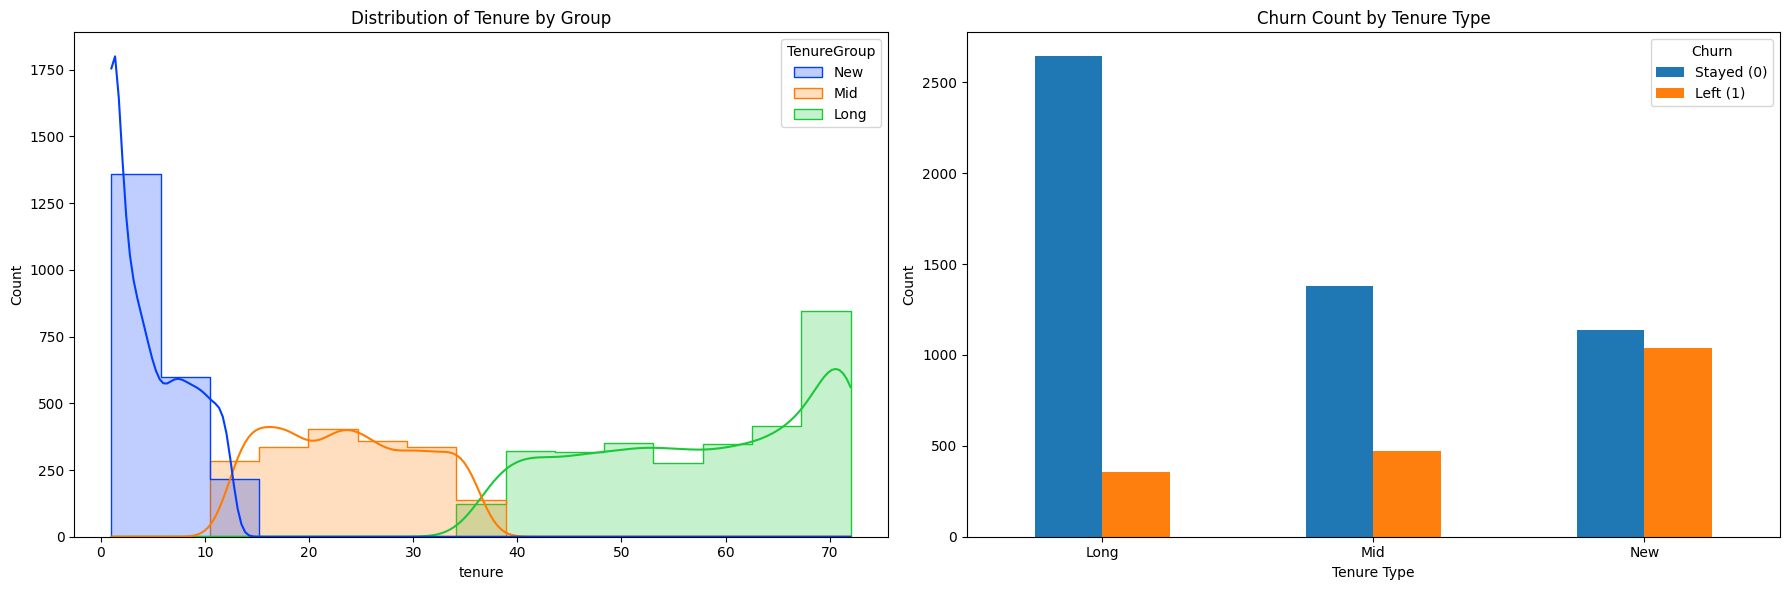

In [845]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# 1. Left Chart: Tenure Distribution (Histogram)
sns.histplot(
    data=df,
    x="tenure",
    hue="TenureGroup",
    element="step",
    kde=True,
    palette="bright",
    legend=True,
    ax=ax[0],  # Assign to the first subplot
)
ax[0].set_title("Distribution of Tenure by Group")

# 2. Right Chart: Churn Count (Bar Chart from crosstab)
# Note: We use the 'ax' parameter to place the pandas plot into the second subplot
Churn_by_tenure.plot(
    kind="bar", stacked=False, rot=0, ax=ax[1]  # Assign to the second subplot
)
ax[1].set_title("Churn Count by Tenure Type")
ax[1].set_xlabel("Tenure Type")
ax[1].set_ylabel("Count")
ax[1].legend(title="Churn", labels=["Stayed (0)", "Left (1)"])

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

it seems like, New Customers is not staying to long term, withing 10 months they are churning and while in long term, customer still showing Loyalty  

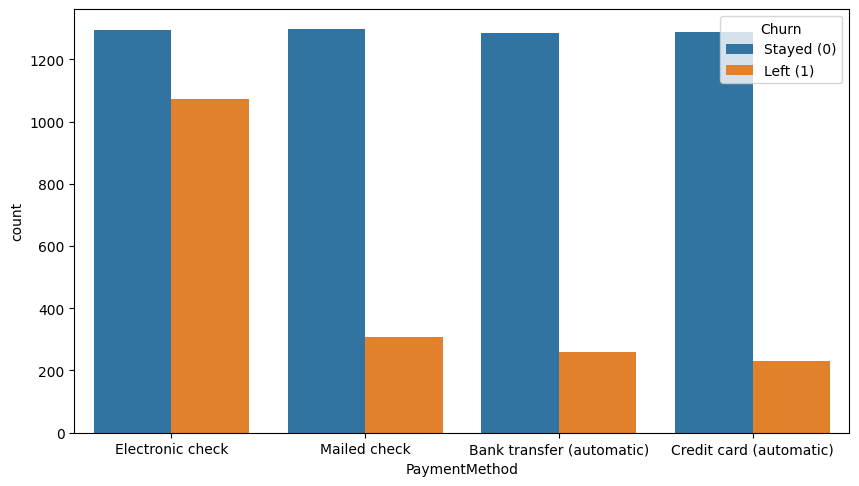

In [846]:
plt.figure(figsize=(10, 5.5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.legend(title="Churn", labels=["Stayed (0)", "Left (1)"])

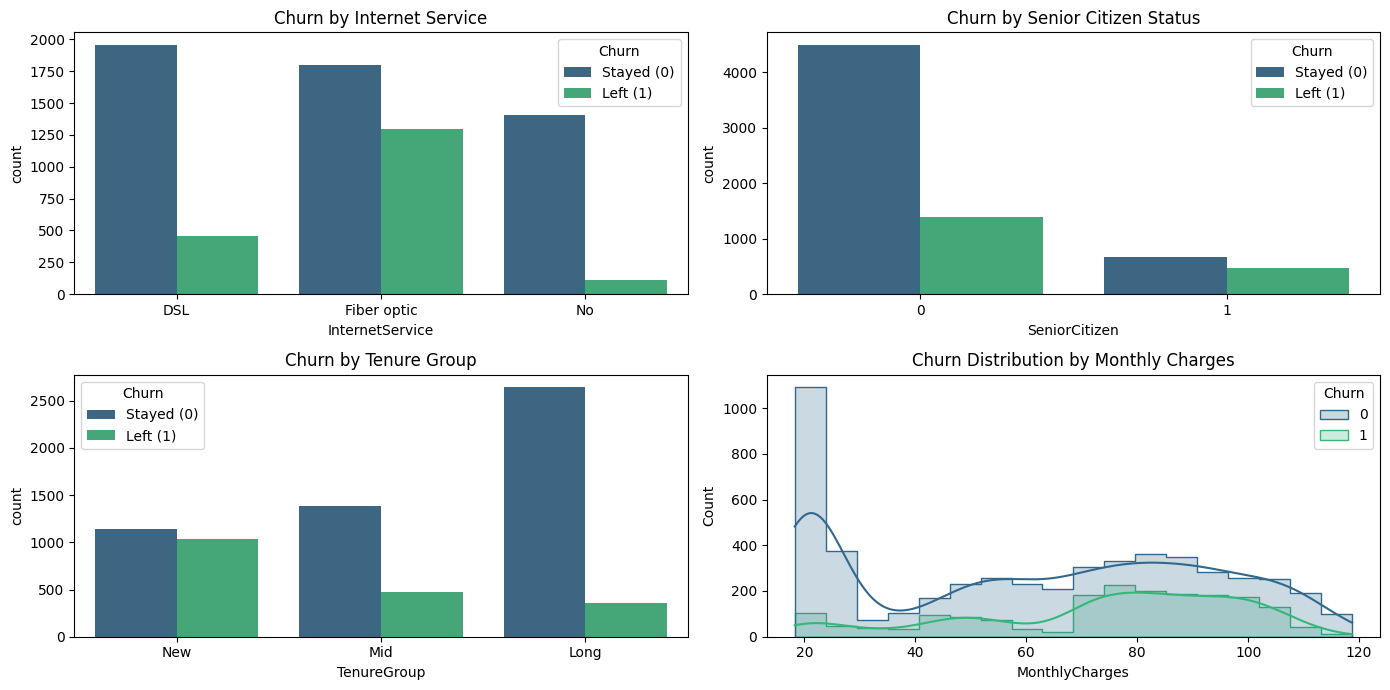

In [847]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 7))
plt.subplots_adjust(hspace=0.4)  # Add space between rows

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    ax=axes[0, 0],
    palette="viridis",
    legend=True,
)
axes[0, 0].set_title("Churn by Internet Service")
axes[0, 0].legend(title="Churn", labels=["Stayed (0)", "Left (1)"])

sns.countplot(data=df, x="SeniorCitizen", hue="Churn", ax=axes[0, 1], palette="viridis")
axes[0, 1].set_title("Churn by Senior Citizen Status")
axes[0, 1].legend(title="Churn", labels=["Stayed (0)", "Left (1)"])


sns.countplot(data=df, x="TenureGroup", hue="Churn", ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Churn by Tenure Group")
axes[1, 0].legend(title="Churn", labels=["Stayed (0)", "Left (1)"])


sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    kde=True,
    ax=axes[1, 1],
    palette="viridis",
    element="step",
)
axes[1, 1].set_title("Churn Distribution by Monthly Charges")


# plt.legend(title="Churn", labels=["Stayed (0)", "Left (1)"])
plt.tight_layout()
plt.show()

* based on internet service we find that fiber optic internetservice customer like Churning compare to DSA internet.
* it seems like, just 1000 senior Citizens are part of subscriptions, rest of all are likely adults and youngsters.
* in montly charges, the average charges are between 70 to 90 Doller, and there are mostly customer Churning. 

In [848]:
service_churn = pd.crosstab(df["ServiceCount"], df["Churn"])
service_churn

Churn,0,1
ServiceCount,,
0,45,35
1,1338,359
2,796,390
3,613,352
4,632,289
5,674,232
6,522,152
7,346,49
8,197,11


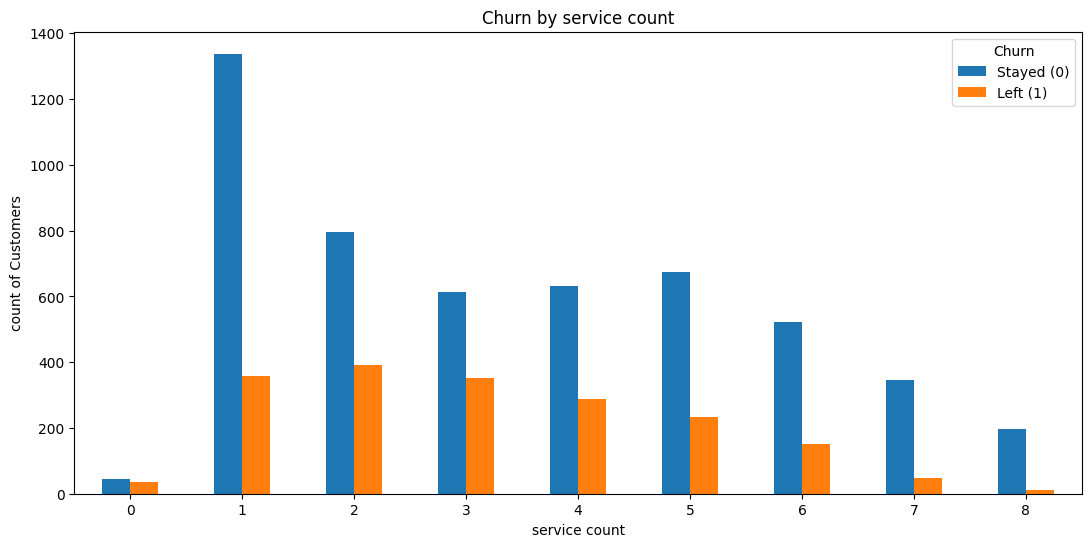

In [849]:
service_churn.plot(
    kind="bar", figsize=(13, 6), rot=0
)  # Standard 'Stayed' vs 'Left' colors

plt.title("Churn by service count")
plt.xlabel("service count")
plt.ylabel("count of Customers")
plt.legend(title="Churn", labels=["Stayed (0)", "Left (1)"])
plt.show()

* customers with only 1 service are the most numerous and largely loyal, but the risk of churn remains steady until a customer reaches a "tipping point" of 6 or more services, at  which point churn becomes negligible
* customers heavily integrated into the ecosystem (7–8 services) are highly unlikely to leave

Preparing Data for Customer Segmentation

In [850]:
df.dropna(inplace=True)

In [851]:
seg_features = df[["tenure", "MonthlyCharges", "TotalCharges", "ServiceCount"]]

In [852]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(seg_features)

In [853]:
scaled_data

array([[-1.28024804, -1.16169394, -0.99419409, -1.14618325],
       [ 0.06430269, -0.26087792, -0.17373982, -0.17621386],
       [-1.23950408, -0.36392329, -0.95964911, -0.17621386],
       ...,
       [-0.87280842, -1.17000405, -0.85451414, -1.14618325],
       [-1.15801615,  0.31916782, -0.87209546, -0.66119856],
       [ 1.36810945,  1.35793167,  2.01234407,  1.27874021]],
      shape=(7032, 4))

Finding Optimal Clusters using Elbow Method and Building Customer Segmentation Model

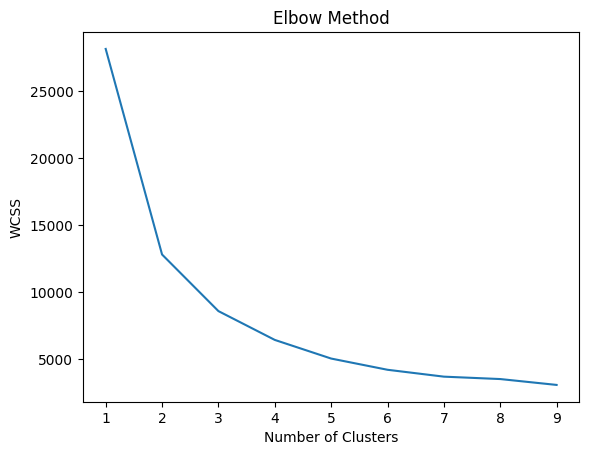

In [854]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [855]:
import joblib

kmeans = joblib.load("KMeans-cluster-model.joblib")

In [859]:
df["Cluster"] = kmeans.fit_predict(scaled_data)

Business KPI

In [861]:
cluster_labels = {
    0: "Loyal High-Value",
    1: "Low Engagement / Higher Risk",
}

df["Segment"] = df["Cluster"].map(cluster_labels)

In [862]:
df["CLV"] = df["TotalCharges"]

In [868]:
kmeans.predict(scaler.transform(np.array([[1, 000.8, 0000.50, 7]])))

d:\AI\tf-usage\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1], dtype=int32)

In [869]:
df.groupby("Cluster")[
    ["tenure", "MonthlyCharges", "TotalCharges", "ServiceCount"]
].mean()

,tenure,MonthlyCharges,TotalCharges,ServiceCount
Cluster,,,,
0,54.468051,90.233826,4895.751198,5.515974
1,20.230124,50.732222,838.605941,2.172924


In [870]:
df.groupby("Segment")[["CLV", "MonthlyCharges"]].mean()

,CLV,MonthlyCharges
Segment,,
Low Engagement / Higher Risk,838.605941,50.732222
Loyal High-Value,4895.751198,90.233826


In [871]:
df["CLV_Tier"] = pd.qcut(df["CLV"], q=3, labels=["Low", "Medium", "High"])

In [877]:
features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "Contract",
    "PaymentMethod",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "DeviceProtection",
    "PaperlessBilling",
    "Partner",
    "Dependents",
]
target = "Churn"

In [878]:
categorical_cols = df[features].select_dtypes(include="object").columns
df_encoded = pd.get_dummies(
    df[features + [target]], columns=categorical_cols, drop_first=True
)

In [881]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [882]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [883]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [884]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train_res, y_train_res)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [885]:
xgb = XGBClassifier(n_estimators=200, random_state=42, scale_pos_weight=3)
xgb.fit(X_train_res, y_train_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [887]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

models = {"Logistic Regression": lr, "Random Forest": rf, "XGBoost": xgb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("\n")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("\n")

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.68      0.59       374

    accuracy                           0.75      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.75      0.76      1407



[[795 238]
 [119 255]]


ROC-AUC: 0.8100077133731254


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1033
           1       0.53      0.59      0.56       374

    accuracy                           0.75      1407
   macro avg       0.69      0.70      0.69      1407
weighted avg       0.76      0.75      0.76      1407



[[839 194]
 [153 221]]


ROC-AUC: 0.8031808604811281


--- XGBoost ---
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.50      0.71      0.59       374

  

In [888]:
df["Churn_Probability"] = rf.predict_proba(X)[:, 1]

In [889]:
df.groupby(["CLV_Tier"])["Churn_Probability"].mean()

C:\Users\pritc\AppData\Local\Temp\ipykernel_8600\113929574.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["CLV_Tier"])["Churn_Probability"].mean()


CLV_Tier
Low       0.446947
Medium    0.269152
High      0.203426
Name: Churn_Probability, dtype: float64

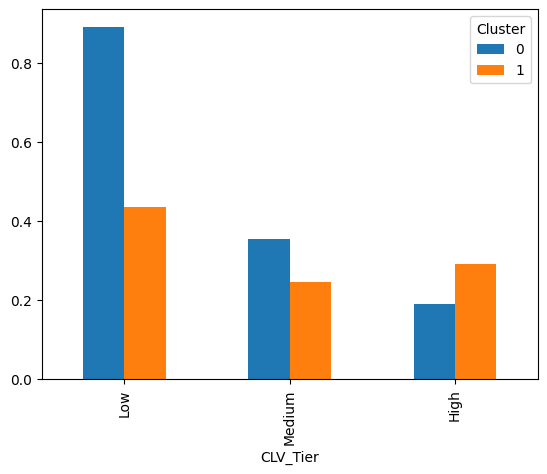

In [543]:
clv_based_clustering = pd.crosstab(
    df["CLV_Tier"], df["Cluster"], values=df["Churn_Probability"], aggfunc="mean"
)
clv_based_clustering.plot(kind="bar")
plt.show()

* it seem like, who have LOW CLV(Customer Life Time Value) is likely to less churning compare to MEDIUM CLV customer from 0th Segmenta
* it seem like, who have HIGH CLV(Customer Life Time Value) is likely to HIgh churning compare to MEDIUM CLV customer from 1th Segmenta because of Their spending

In [895]:
df["Revenue_At_Risk"] = df["CLV"] * df["Churn_Probability"]

In [898]:
df.sort_values("Revenue_At_Risk", ascending=False).head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Churn,TenureGroup,ServiceCount,AvgCharges,Cluster,Segment,CLV,CLV_Tier,Churn_Probability,Revenue_At_Risk
5697,1984-FCOWB,Female,0,Yes,No,70,Yes,Yes,Fiber optic,No,...,1,Long,7,109.636429,0,Loyal High-Value,7674.55,High,0.990,7597.8045
6537,1444-VVSGW,Male,0,Yes,No,70,Yes,Yes,Fiber optic,Yes,...,1,Long,8,113.840714,0,Loyal High-Value,7968.85,High,0.940,7490.7190
4395,5502-RLUYV,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,No,...,1,Long,6,107.926087,0,Loyal High-Value,7446.90,High,0.960,7149.0240
4610,2889-FPWRM,Male,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,1,Long,8,120.622222,0,Loyal High-Value,8684.80,High,0.790,6860.9920
3890,3886-CERTZ,Female,0,Yes,No,72,Yes,Yes,Fiber optic,No,...,1,Long,7,112.636111,0,Loyal High-Value,8109.80,High,0.835,6771.6830


In [561]:
# df.to_csv("Telo-customer-at-risk.csv", index=False)

In [16]:
o_df = pd.read_csv("D:\\database\\csv files\\customer_churn-training.csv")
df = o_df.copy()

In [17]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [18]:
df.dropna(inplace=True)

In [19]:
df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

Churn               1.000000
Support Calls       0.574267
Payment Delay       0.312129
Age                 0.218394
Last Interaction    0.149616
Usage Frequency    -0.046101
Tenure             -0.051919
Total Spend        -0.429355
CustomerID         -0.839365
Name: Churn, dtype: float64

<Axes: xlabel='Support Calls', ylabel='Churn'>

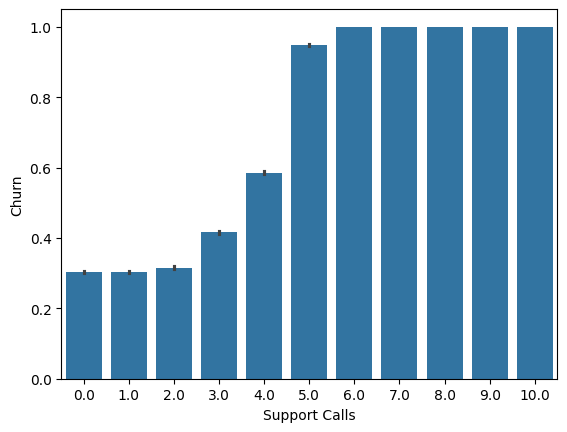

In [6]:
sns.barplot(y=df["Churn"], x=df["Support Calls"])

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 43.7+ MB


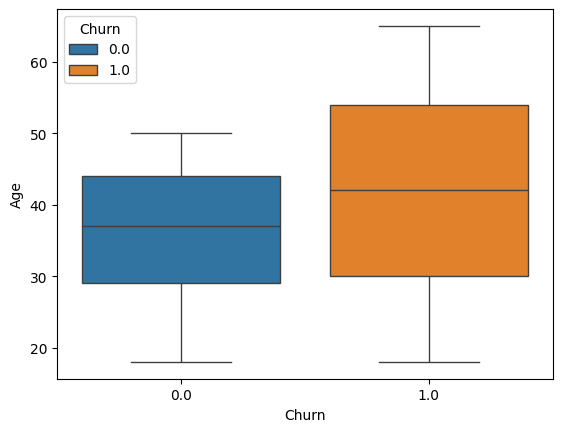

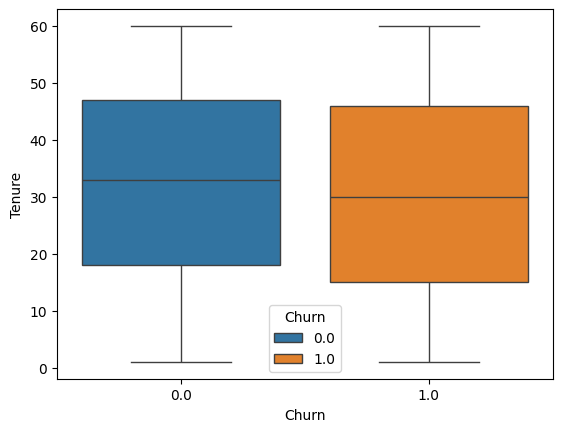

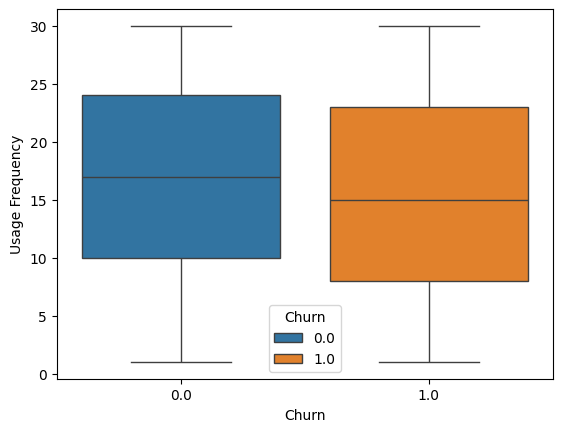

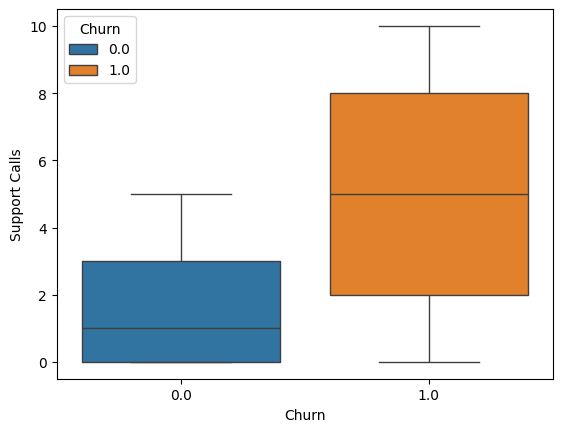

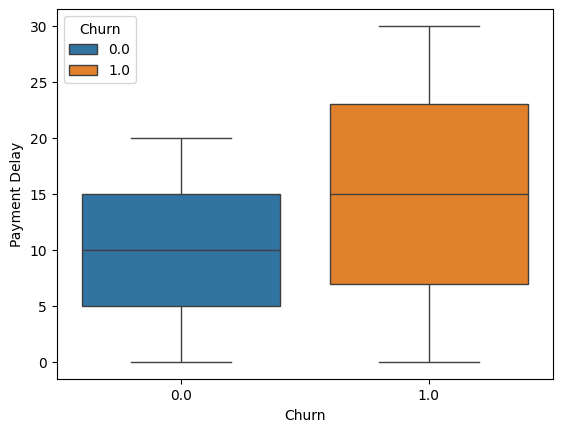

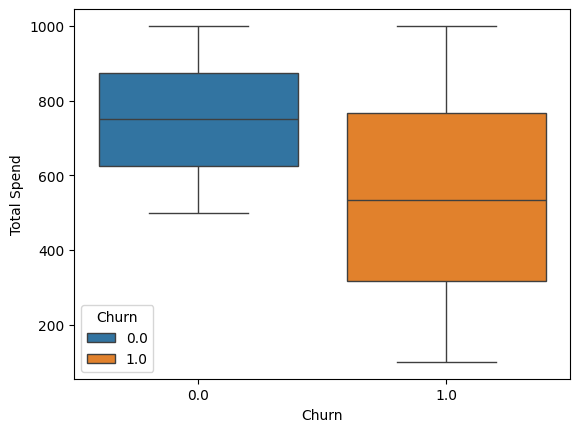

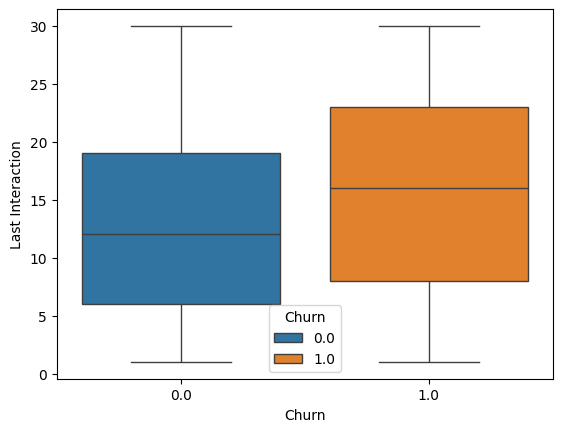

In [48]:
numeric_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction",
]
numeric_cols = [c for c in numeric_features if c != "Churn"]

for col in numeric_cols:
    sns.boxplot(x="Churn", y=col, data=df, hue="Churn")
    plt.show()

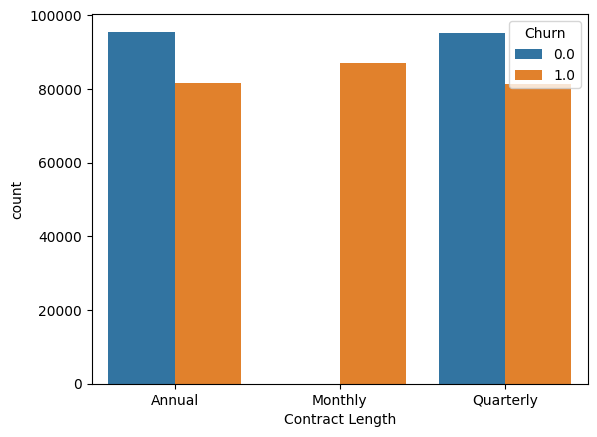

In [13]:
sns.countplot(data=df, x="Contract Length", hue="Churn")
plt.show()

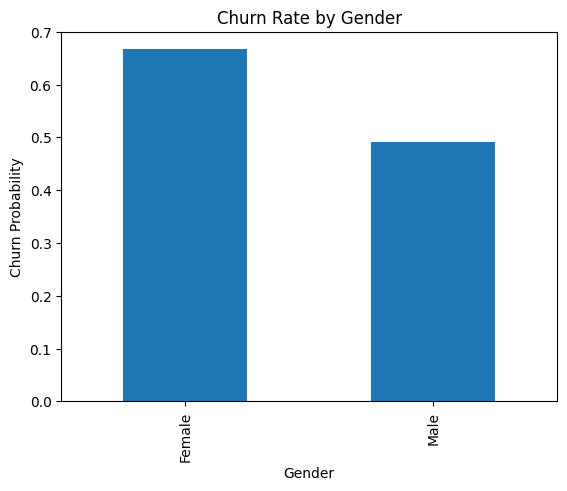

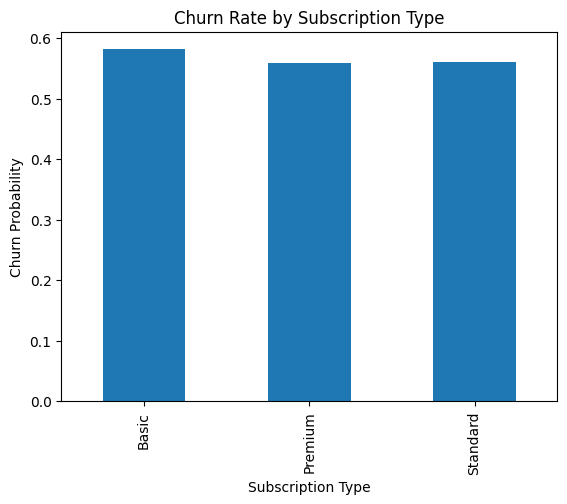

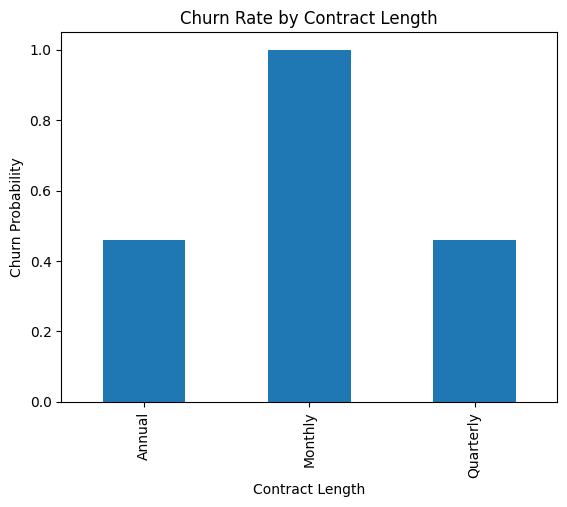

In [46]:
categorical_features = ["Gender", "Subscription Type", "Contract Length"]
for col in categorical_features:
    churn_rate = df.groupby(col)["Churn"].mean()
    churn_rate.plot(kind="bar")
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Probability")
    plt.show()

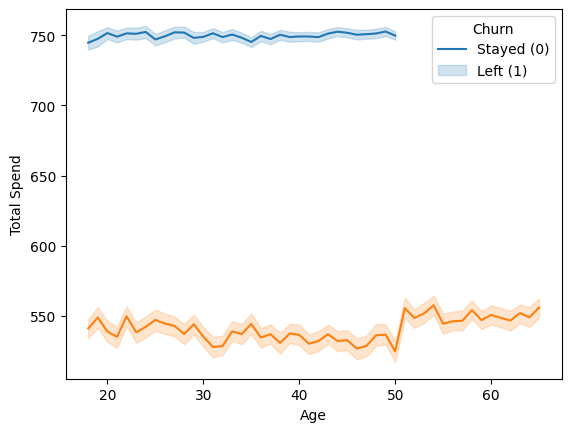

In [15]:
sns.lineplot(data=df, x="Age", y="Total Spend", hue="Churn")
plt.legend(title="Churn", labels=["Stayed (0)", "Left (1)"])
plt.show()

In [22]:
df["Churn"].value_counts(normalize=True)

Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64

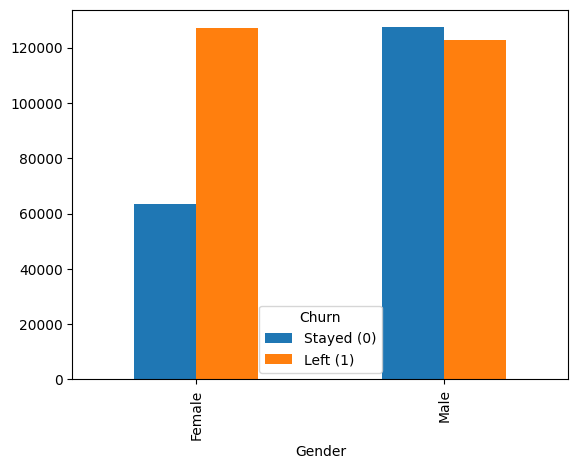

In [25]:
gender_churn = df.groupby(["Gender", "Churn"]).size().unstack()
gender_churn.plot(kind="bar")
plt.legend(title="Churn", labels=["Stayed (0)", "Left (1)"])
plt.show()

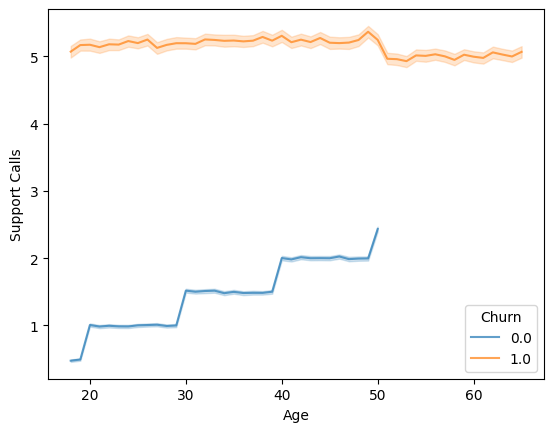

In [37]:
sns.lineplot(data=df, y="Support Calls", x="Age", hue="Churn", alpha=0.7)
plt.show()

In [20]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

In [21]:
numeric_feature = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Total Spend",
]

categorical_cols = ["Gender", "Subscription Type", "Contract Length"]
nemeric_imputer_trf = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="mean"),
        )
    ]
)

nemeric_scaler_trf = Pipeline(steps=[("scaler", RobustScaler())])

categorical_trf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        ),
    ]
)

data_process_pipline = ColumnTransformer(
    transformers=[
        ("cat", categorical_trf, categorical_cols),
        ("scaler", nemeric_scaler_trf, numeric_feature),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

In [22]:
x = df.drop(
    columns=[
        "Churn",
        "Support Calls",
        "Payment Delay",
        "Last Interaction",
        "CustomerID",
    ],
    axis=1,
)
y = df["Churn"].astype(int)


X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [74]:
clf1 = RandomForestClassifier()
clf3 = BaggingClassifier()
voting_clasifier = VotingClassifier(
    estimators=[
        ("RandomForestClassifier", clf1),
        ("XGBClassifier", clf3),
    ],
    voting="soft",
)

In [76]:
import mlflow

mlflow.set_experiment("customer_churn_models")
mlflow.sklearn.autolog()

full_pipeline = Pipeline(
    steps=[
        ("transformation", data_process_pipline),
        ("model", voting_clasifier),
    ]
)
full_pipeline.fit(X_train, y_train)

2026/02/23 15:00:21 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e66de1559dd1457297420417fff8f690', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


,steps,"[('transformation', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [77]:
prediction = full_pipeline.predict(X_test)


In [83]:
confusion_matrix(prediction, y_test)

array([[36486,  9075],
       [ 1598, 41008]])

In [84]:
print(classification_report(prediction, y_test))

              precision    recall  f1-score   support

           0       0.96      0.80      0.87     45561
           1       0.82      0.96      0.88     42606

    accuracy                           0.88     88167
   macro avg       0.89      0.88      0.88     88167
weighted avg       0.89      0.88      0.88     88167



In [221]:
model = full_pipeline.named_steps["model"]
transformation = full_pipeline.named_steps["transformation"]

In [222]:
model.predict_proba(
    np.array([[1.0, 1.0, 1.0, -0.368421, -0.066667, -1.000000, -1.151429]])
)

d:\AI\tf-usage\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\AI\tf-usage\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


array([[0., 1.]])

In [90]:
df["Churn"].value_counts(normalize=True)

Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64

<Axes: >

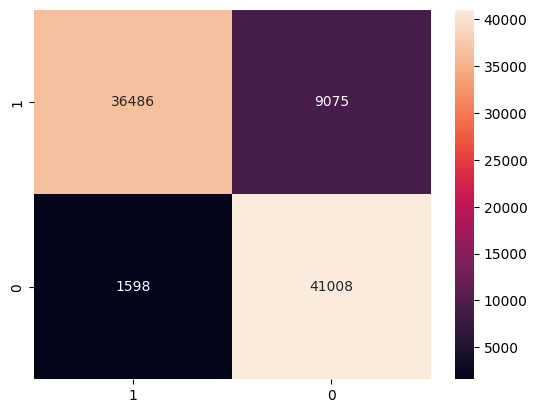

In [89]:
sns.heatmap(
    confusion_matrix(prediction, y_test),
    annot=True,
    fmt="d",
    xticklabels=[1, 0],
    yticklabels=[1, 0],
)

In [2]:
import joblib

old_model = joblib.load("Churn-system/churn_clf.joblib")

In [34]:
transformation = old_model.named_steps["transformation"]

In [ ]:
old_model_pred = old_model.predict(X_test)

<Axes: >

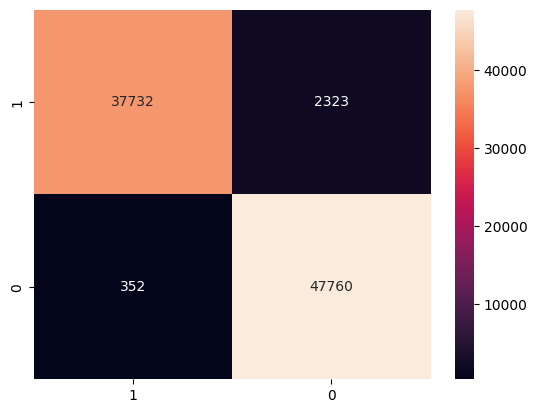

In [104]:
sns.heatmap(
    confusion_matrix(old_model_pred, y_test),
    annot=True,
    fmt="d",
    xticklabels=[1, 0],
    yticklabels=[1, 0],
)

In [107]:
print(classification_report(old_model_pred, y_test))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97     40055
           1       0.95      0.99      0.97     48112

    accuracy                           0.97     88167
   macro avg       0.97      0.97      0.97     88167
weighted avg       0.97      0.97      0.97     88167



* previous model is still perfoming good, so we are not replacing previos model

In [106]:
# import joblib

# joblib.dump(full_pipeline, "churn_clf.joblib")

# l = joblib.load("Churn-system/churn_clf.joblib")
# feature_pip = l.named_steps["transformation"]
# model = l.named_steps["model"]

* Value based Segmentation

In [ ]:
df_segment = df[["Tenure", "Usage Frequency", "Total Spend"]]

scaler = RobustScaler()
scaled_df = scaler.fit_transform(df_segment)

In [121]:
mlflow.autolog(disable=True)
mlflow.sklearn.autolog(disable=True)
mlflow.pytorch.autolog(disable=True)

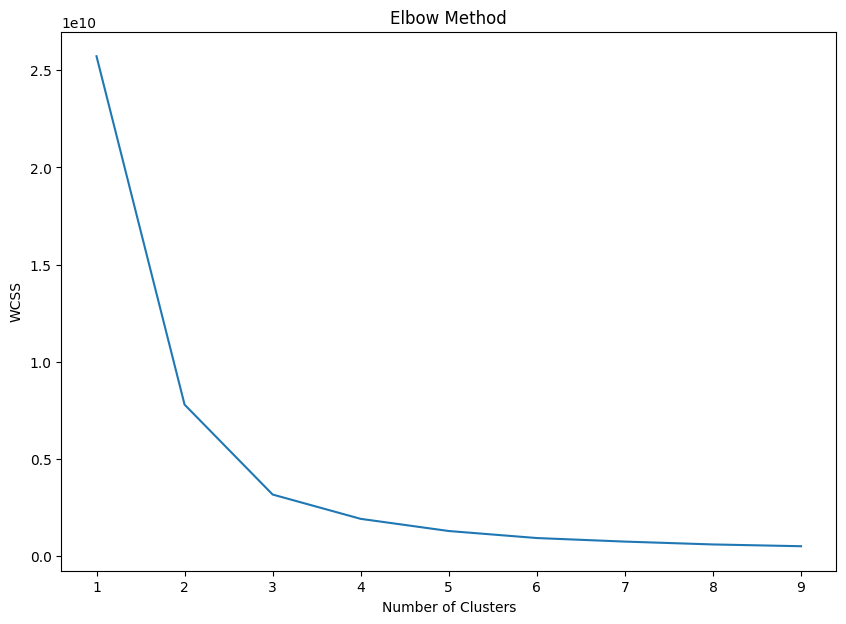

In [130]:
wcss = []
plt.figure(figsize=(10, 7))

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_segment)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [133]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(df_segment)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [134]:
df["Segment"] = kmeans.predict(df_segment)

In [60]:
loded_kmeans = joblib.load("Churn-system/KMeans-cluster-model.joblib")

In [182]:
# joblib.dump(kmeans, "KMeans-cluster-model.joblib")

In [135]:
df.groupby("Segment")[["Tenure", "Usage Frequency", "Total Spend"]].mean()

,Tenure,Usage Frequency,Total Spend
Segment,,,
0,31.503816,15.920209,792.579527
1,30.867833,15.630549,378.930456


In [156]:
df["Churn_Probability"] = l.predict_proba(x)[:, 1]

In [90]:
segment = {
    0: "Elite High-Value Tier",
    1: "Standard Middle-Value Tier",
}
# df["Segment_tier"] = df["Segment"].map(segment)
segment.get(9, "Standard Middle-Value Tier")

'Standard Middle-Value Tier'

In [ ]:
df.groupby("Segment")["Churn_Probability"].mean()

In [164]:
mapping = {"Monthly": 1, "Quarterly": 3, "Annual": 12}
df["Contract_Months"] = df["Contract Length"].map(mapping)

df["Avg_Monthly_Revenue"] = df["Total Spend"] / df["Tenure"]

In [160]:
df["Rvenue_at_risk"] = df["Churn_Probability"] * df["Total Spend"]

In [161]:
df.groupby("Segment").agg(
    {
        "Total Spend": "mean",
        "Churn_Probability": "mean",
        "Rvenue_at_risk": "sum",  # This shows the total ₹ at stake per group
    }
).sort_values("Rvenue_at_risk", ascending=False).round(2)

,Total Spend,Churn_Probability,Rvenue_at_risk
Segment,,,
0,792.58,0.42,88036583.91
1,378.93,0.81,48098784.75


In [179]:
df.sort_values("Rvenue_at_risk", ascending=False).head(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Segment,Churn_Probability,Segment_tier,Contract_Months,Avg_Monthly_Revenue,Rvenue_at_risk
81410,83543.0,65.0,Female,4.0,3.0,7.0,21.0,Premium,Monthly,993.00,24.0,1.0,0,0.880266,Elite High-Value Tier,1,248.250000,874.104271
97742,100621.0,65.0,Female,7.0,6.0,1.0,19.0,Basic,Quarterly,993.00,12.0,1.0,0,0.879557,Elite High-Value Tier,3,141.857143,873.400375
182819,187630.0,63.0,Female,2.0,1.0,5.0,12.0,Basic,Quarterly,997.00,2.0,1.0,0,0.875711,Elite High-Value Tier,3,498.500000,873.083820
150434,155245.0,64.0,Female,6.0,1.0,1.0,9.0,Standard,Quarterly,1000.00,23.0,1.0,0,0.871603,Elite High-Value Tier,3,166.666667,871.603278
199580,204404.0,64.0,Female,3.0,2.0,1.0,14.0,Premium,Monthly,991.44,1.0,1.0,0,0.879126,Elite High-Value Tier,1,330.480000,871.601129


In [6]:
from mlflow.tracking import MlflowClient
import mlflow

client = MlflowClient()

experiment = client.get_experiment_by_name("customer_churn_models")

In [183]:
mlflow.set_tracking_uri("http://localhost:5000")

In [215]:
client.set_registered_model_alias(name="Voting-clf", alias="production", version=1)

In [242]:
import gc

gc.collect()

0

In [54]:
mlflow_model = mlflow.pyfunc.load_model("models:/Voting-clf@production")

In [44]:
old_model.predict_proba((x.iloc[5:9, :]))

array([[0.02095601, 0.97904399],
       [0.11646371, 0.88353629],
       [0.02832758, 0.97167242],
       [0.28584062, 0.71415938]])

In [50]:
model.feature_names_in_

array(['Gender', 'Subscription Type', 'Contract Length', 'Age', 'Tenure',
       'Usage Frequency', 'Total Spend'], dtype=object)

In [57]:
mlflow_model.predict(transformation.transform(x.iloc[1:9, :]))

array([1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
mlflow.get_experiment_by_name("customer_churn_models")

<Experiment: artifact_location='file:///D:/churn_model/mlruns/602447457529049309', creation_time=1770224284648, experiment_id='602447457529049309', last_update_time=1770224284648, lifecycle_stage='active', name='customer_churn_models', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [64]:
j = {
    "gender": "Male",
    "SeniorCitizen": "0",
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 12,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 75.5,
    "TotalCharges": 900.0,
}

import requests

responce = requests.post(url="http://localhost:8000/api/predict", json=j)

In [65]:
responce.json()

{'status': 'success',
 'data': {'churn_probability_pct': 54.8,
  'risk_level': 'High Risk ⚠️',
  'segment': 'Low Engagement / Higher Risk',
  'kpis': {'clv': 900.0,
   'clv_tier': 'Medium',
   'revenue_at_risk': 493.01,
   'expected_ltv': 62.33,
   'monthly_charges': 75.5,
   'net_retention_value': 8.7},
  'shap_factors': ['PaperlessBilling is increasing churn risk (impact: +0.093)']}}

In [1]:
import pandas as pd
from pathlib import Path


# DATA_PATH = "C:\\Users\\pritc\\Downloads\\churn_predictions (3).xlsx"
# # Path(DATA_PATH).exists()
# df = pd.read_excel(DATA_PATH)

In [9]:
REQUIRED_FILES = [
    "/churn_model/Churn-system/models/churn_clf.joblib",
    "/churn_model//Churn-system/models/KMeans-cluster-model.joblib",
    "/churn_model//Churn-system/shape-background/shap_background.csv",
]
for f in REQUIRED_FILES:
    if Path(f).exists():
        print(f"  ✅  {f}")
    else:
        print(f"  ❌  {f}  — MISSING")

  ✅  /churn_model/Churn-system/models/churn_clf.joblib
  ✅  /churn_model//Churn-system/models/KMeans-cluster-model.joblib
  ✅  /churn_model//Churn-system/shape-background/shap_background.csv
